In [ ]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 81.5 MB/s eta 0:00:00


In [ ]:
import os
import re
from datetime import datetime
import rasterio
from rasterio.coords import BoundingBox
from collections import defaultdict
from rasterio.warp import transform_bounds
from shapely.geometry import box
from rasterio.mask import mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
import json
from shapely.geometry import shape, mapping
import geopandas as gpd
import xml.etree.ElementTree as ET
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [ ]:
folder = ['/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations']
L8_filenames = [os.path.join(folder[0], f) for f in os.listdir(folder[0]) if f.startswith('LC08') ]
L8_filenames

['/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/LC08_171017_20230305_Cloud_Mask.tif',
 '/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/LC08_104011_20230706_Cloud_Mask.tif',
 '/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/LC08_071245_20230815_Cloud_Mask.tif',
 '/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/LC08_045003_20230910_Cloud_Mask.tif']

In [ ]:
ps_filenames = [os.path.join(folder[0], f) for f in os.listdir(folder[0]) if f.endswith('udm2')]
ps_filenames

['/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230910_183459_83_2402_psscene_analytic_udm2',
 '/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230305_074907_10_2414_psscene_analytic_udm2',
 '/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230815_230149_29_248f_psscene_analytic_udm2',
 '/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230706_004229_87_2483_psscene_analytic_udm2']

In [ ]:
def extract_date(path):
    """Extract YYYYMMDD as datetime from filename or folder name."""
    basename = os.path.basename(path)
    # print(basename)
    match = re.search(r'(\d{8})', basename)
    return datetime.strptime(match.group(1), '%Y%m%d') if match else None

matches = []

def overlap_ratio(bbox1: BoundingBox, bbox2: BoundingBox) -> float:
    # Find intersection boundaries
    inter_left = max(bbox1.left, bbox2.left)
    inter_right = min(bbox1.right, bbox2.right)
    inter_bottom = max(bbox1.bottom, bbox2.bottom)
    inter_top = min(bbox1.top, bbox2.top)

    # Check if they intersect
    if inter_left >= inter_right or inter_bottom >= inter_top:
        return 0.0  # No intersection

    # Compute intersection area
    inter_area = (inter_right - inter_left) * (inter_top - inter_bottom)

    # Compute area of each box
    area1 = (bbox1.right - bbox1.left) * (bbox1.top - bbox1.bottom)
    area2 = (bbox2.right - bbox2.left) * (bbox2.top - bbox2.bottom)

    # Compute ratio (intersection over union or over min box)
    return inter_area / min(area1, area2)  # or use max(area1, area2) or (area1 + area2 - inter_area)


for path in ps_filenames:
    print(path)
    ps_path = [os.path.join(path+'/PSScene', f) for f in os.listdir(path+'/PSScene') if f.endswith('MS_clip.tif') ][0]
    ps_date = extract_date(ps_path)
    with rasterio.open(ps_path) as ps_src:
        ps_bbox = ps_src.bounds
        ps_crs = ps_src.crs
        ps_bbox_wgs84 = transform_bounds(ps_crs, "EPSG:4326",
                                 ps_bbox.left, ps_bbox.bottom,
                                 ps_bbox.right, ps_bbox.top,
                                 densify_pts=21)  # improves accuracy for curved boundaries

        # Re-wrap result into BoundingBox for consistency
        ps_bbox_wgs84 = BoundingBox(*ps_bbox_wgs84)

    for l8_path in L8_filenames:
        l8_date = extract_date(l8_path)
        if l8_date != ps_date:
            continue
        with rasterio.open(l8_path) as l8_src:
            l8_bbox = l8_src.bounds
            print('compare to:', l8_path)
            if overlap_ratio(ps_bbox_wgs84, l8_bbox)>0.9:
                print(f"Matched: {ps_path} and {l8_path}")
                matches.append((ps_path, l8_path))

/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230910_183459_83_2402_psscene_analytic_udm2
compare to: /content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/LC08_045003_20230910_Cloud_Mask.tif
Matched: /content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230910_183459_83_2402_psscene_analytic_udm2/PSScene/20230910_183459_83_2402_3B_AnalyticMS_clip.tif and /content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/LC08_045003_20230910_Cloud_Mask.tif
/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230305_074907_10_2414_psscene_analytic_udm2
compare to: /content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/LC08_171017_20230305_Cloud_Mask.tif
Matched: /content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230305_074907_10_2414_psscene_analytic_udm2/PSScene/20230305_074907_10_2414_3B_AnalyticMS_clip.tif and /content/drive/MyDrive/ice_clo

/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230910_183459_83_2402_psscene_analytic_udm2/PSScene
/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230910_183459_83_2402_psscene_analytic_udm2/PSScene/20230910_183459_83_2402_3B_AnalyticMS_clip.tif
/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230910_183459_83_2402_psscene_analytic_udm2/PSScene/20230910_183459_83_2402_3B_AnalyticMS_metadata_clip.xml
/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/LC08_045003_20230910_Cloud_Mask.tif


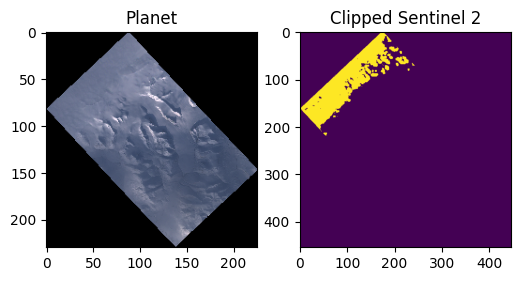

reflectance_coefficients: [[[6.52801849e-05 7.08014308e-05 8.52192969e-05 1.34880720e-04]]]


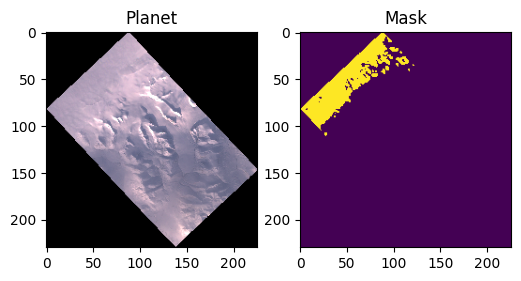

/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230910_183459_83_2402.tfrecords
/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230305_074907_10_2414_psscene_analytic_udm2/PSScene
/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230305_074907_10_2414_psscene_analytic_udm2/PSScene/20230305_074907_10_2414_3B_AnalyticMS_clip.tif
/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230305_074907_10_2414_psscene_analytic_udm2/PSScene/20230305_074907_10_2414_3B_AnalyticMS_metadata_clip.xml
/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/LC08_171017_20230305_Cloud_Mask.tif


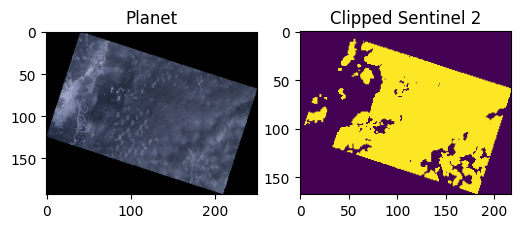

reflectance_coefficients: [[[4.24099915e-05 4.59969297e-05 5.53636553e-05 8.76267458e-05]]]


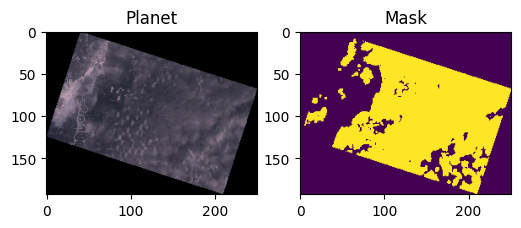

/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230305_074907_10_2414.tfrecords
/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230815_230149_29_248f_psscene_analytic_udm2/PSScene
/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230815_230149_29_248f_psscene_analytic_udm2/PSScene/20230815_230149_29_248f_3B_AnalyticMS_clip.tif
/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230815_230149_29_248f_psscene_analytic_udm2/PSScene/20230815_230149_29_248f_3B_AnalyticMS_metadata_clip.xml
/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/LC08_071245_20230815_Cloud_Mask.tif


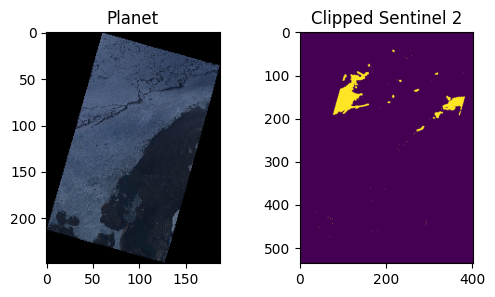

reflectance_coefficients: [[[6.05765978e-05 6.57000252e-05 7.90790510e-05 1.25162254e-04]]]


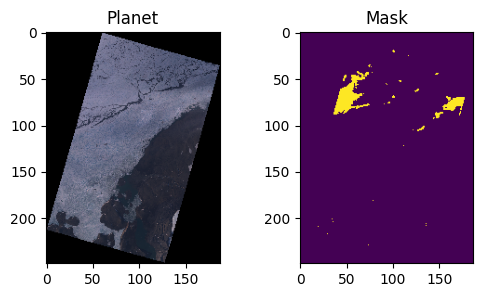

/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230815_230149_29_248f.tfrecords
/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230706_004229_87_2483_psscene_analytic_udm2/PSScene
/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230706_004229_87_2483_psscene_analytic_udm2/PSScene/20230706_004229_87_2483_3B_AnalyticMS_clip.tif
/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230706_004229_87_2483_psscene_analytic_udm2/PSScene/20230706_004229_87_2483_3B_AnalyticMS_metadata_clip.xml
/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/LC08_104011_20230706_Cloud_Mask.tif


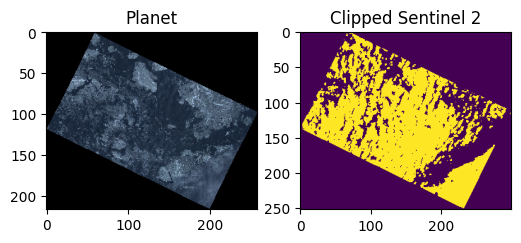

reflectance_coefficients: [[[2.44364440e-05 2.65032215e-05 3.19002861e-05 5.04901319e-05]]]


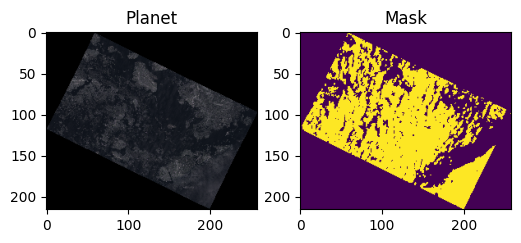

/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230706_004229_87_2483.tfrecords


In [ ]:
import tensorflow as tf
def _int_feature(value):
    return tf.train.Feature(
        int64_list=tf.train.Int64List(value=value.reshape(-1))
    )

def image_example(image_array, mask):
    feature = {
        'image_raw': _int_feature(image_array),
        'label': _int_feature(mask),
    }

    return tf.train.Example(features=tf.train.Features(feature=feature))

def rcoef(input_img_array, input_xml_path):
    tree = ET.parse(input_xml_path)
    band_metadata = tree.findall('.//{http://schemas.planet.com/ps/v1/planet_product_metadata_geocorrected_level}bandSpecificMetadata')

    # Extract reflectanceCoefficient from each bandSpecificMetadata element
    reflectance_coefficients = []
    for band in band_metadata:
        reflectance_coefficient_element = band.find('{http://schemas.planet.com/ps/v1/planet_product_metadata_geocorrected_level}reflectanceCoefficient')
        if reflectance_coefficient_element is not None:
            reflectance_coefficient = reflectance_coefficient_element.text
            reflectance_coefficients.append(float(reflectance_coefficient))
    reflectance_coefficients = np.array(reflectance_coefficients).reshape([1, 1, 4])
    print('reflectance_coefficients:', reflectance_coefficients)

    reflectance_img = input_img_array*reflectance_coefficients

    return (reflectance_img*10000).astype(int)


for ps_path, l8_path in matches:
    # print(ps_path, l8_path)
    ps_folder = os.path.dirname(ps_path)
    print(ps_folder)
    planet_img = ps_path
    print(planet_img)
    xml_file = [os.path.join(ps_folder, f) for f in os.listdir(ps_folder) if f.endswith('.xml') ][0]
    print(xml_file)
    mask_img = l8_path
    print(mask_img)

    with rasterio.open(planet_img) as src:
        img1 = src.read()
        # Get the bounds of the second image
        bounds = src.bounds
        # Create a bounding box geometry
        geom = box(*bounds)
        # Transform the geometry to a GeoJSON format
        geom_geojson = geom.__geo_interface__
        clip_crs = src.crs

    # Open the first image
    with rasterio.open(mask_img) as src:
        base_crs = src.crs

        # Reproject if CRS are different
        if base_crs != clip_crs:
            transform, width, height = calculate_default_transform(
                base_crs, clip_crs, src.width, src.height, *src.bounds)
            kwargs = src.meta.copy()
            kwargs.update({
                'crs': clip_crs,
                'transform': transform,
                'width': width,
                'height': height
            })

            # Create an in-memory file to store the reprojected image
            with rasterio.MemoryFile() as memfile:
                with memfile.open(**kwargs) as dest:
                    for i in range(1, src.count + 1):
                        reproject(
                            source=rasterio.band(src, i),
                            destination=rasterio.band(dest, i),
                            src_transform=src.transform,
                            src_crs=base_crs,
                            dst_transform=transform,
                            dst_crs=clip_crs,
                            resampling=Resampling.nearest)
                    img2, out_transform = mask(dest, [geom_geojson], crop=True)
        else:
            # Clip the image using the geometry and Rasterio's mask function
            img2, out_transform = mask(src, [geom_geojson], crop=True)
        out_meta = src.meta.copy()

    img1 = img1.transpose((1, 2, 0))
    img2 = img2.transpose((1, 2, 0))
    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(img1[::50, ::50, 2::-1]/20000)  # Assuming it's a single band image
    plt.title('Planet')

    plt.subplot(1, 2, 2)
    plt.imshow(img2[::10, ::10])  # The clipped image data
    plt.title('Clipped Sentinel 2')

    plt.show()

    img1_ref = rcoef(img1, xml_file)
    img2_resize = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(img1_ref[::50, ::50, 2::-1]/10000)  # Assuming it's a single band image
    plt.title('Planet')

    plt.subplot(1, 2, 2)
    plt.imshow(img2_resize[::50, ::50])  # The clipped image data
    plt.title('Mask')

    plt.show()

    tfpath = os.path.dirname(ps_folder)[:-22]+'.tfrecords'
    print(tfpath)

    with tf.io.TFRecordWriter(tfpath) as all_writer:
        for x in range(0, img1_ref.shape[0] - 400 + 1, 400):
            for y in range(0, img1_ref.shape[1] - 400 + 1, 400):
                img_patch = img1_ref[x:(x + 400), y:(y + 400), :]
                nonzero_ratio = np.count_nonzero(img_patch)/(400*400*4)
                # print(nonzero_ratio)
                if nonzero_ratio > 0.5:
                    cmask = img2_resize[x:(x + 400), y:(y + 400)]

                    tf_example = image_example(img_patch, cmask)
                    all_writer.write(tf_example.SerializeToString())

In [ ]:
    tfpath = os.path.dirname(ps_folder)[:-22]+'.tfrecords'
    print(tfpath)

/content/drive/MyDrive/ice_cloud/time_difference_tiles/5min/New_locations/20230629_233419_91_2439.tfrecords
